# FlameTrack – Dewarping & Rotation Debug

Dieses Notebook testet die `rotate_points`- und Dewarping-Pipeline ohne GUI.

**Ablauf:**
1. IR-Frame laden und Original + Rotiert anzeigen
2. Eckpunkte im rotierten Bild interaktiv klicken
3. `rotate_points` anwenden und Rücktransformation im Originalbild prüfen
4. Dewarping durchführen und Ergebnis beurteilen

**Voraussetzung:** `pip install -e ".[dev]"` und `pip install ipympl`

In [3]:
%matplotlib widget

import numpy as np
import cv2
import matplotlib.pyplot as plt

from flametrack.analysis.ir_analysis import (
    read_ir_data,
    get_dewarp_parameters,
    compute_remap_from_homography,
)
from flametrack.gui.plotting_utils import rotate_points, sort_corner_points

print('Imports OK')

Imports OK


## Zelle 2 – Frame laden

Passe `FRAME_PATH` und `ROTATION_INDEX` an deinen Datensatz an.

Original shape : (768, 1024)  (H=768, W=1024)
Rotiert  shape : (1024, 768)


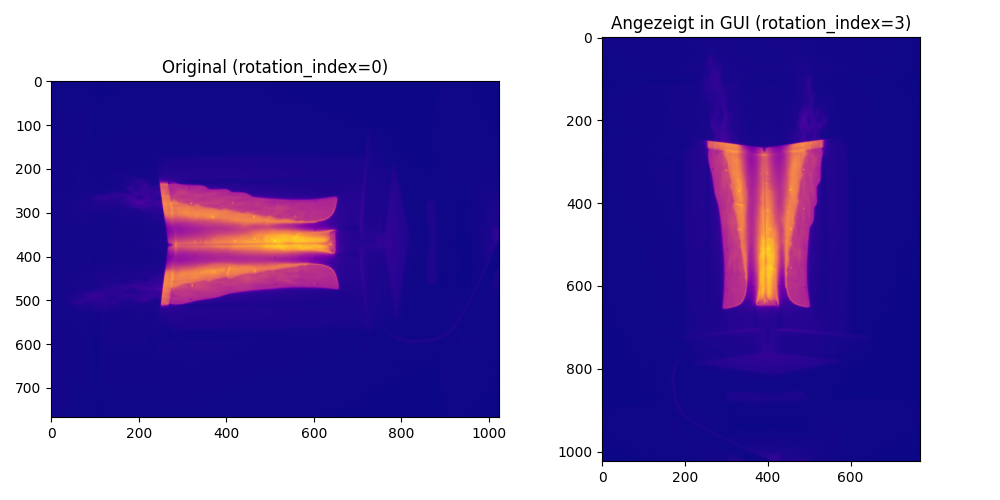

In [8]:
# ── Anpassen ──────────────────────────────────────────────────────────────────
FRAME_PATH     = "/Volumes/Fehr_Daten/Data/BESKID/RST_25_Nov/03)PMMA_DE_10mm_RCE_1m_R1/ir_camera_fzj/exported_data/PMMA_DE_10mm_R1_0007_047.csv"   # Pfad zu einem einzelnen CSV-Frame
ROTATION_INDEX = 3                           # 0=keine, 1=90°CCW, 2=180°, 3=270°CCW
# ──────────────────────────────────────────────────────────────────────────────

raw     = read_ir_data(FRAME_PATH)
rotated = np.rot90(raw, k=ROTATION_INDEX)

print(f"Original shape : {raw.shape}  (H={raw.shape[0]}, W={raw.shape[1]})")
print(f"Rotiert  shape : {rotated.shape}")

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(raw,     cmap='plasma', origin='upper')
axes[0].set_title('Original (rotation_index=0)')
axes[1].imshow(rotated, cmap='plasma', origin='upper')
axes[1].set_title(f'Angezeigt in GUI (rotation_index={ROTATION_INDEX})')
plt.tight_layout()
plt.show()

## Zelle 3 – Eckpunkte interaktiv klicken

- **Room Corner:** 6 Punkte, im Uhrzeigersinn von **oben-links** startend:  
  `oben-links → oben-mitte → oben-rechts → unten-rechts → unten-mitte → unten-links`
- **Lateral Flame Spread:** 4 Punkte, Uhrzeigersinn

Nach dem Ausführen: in das Bild klicken, Enter zum Bestätigen.

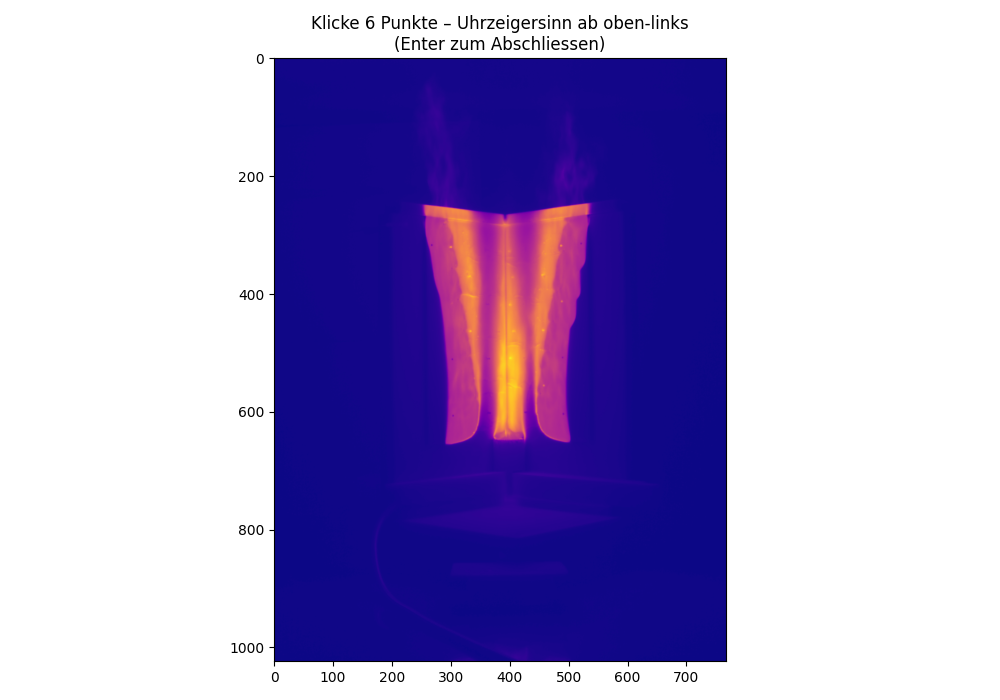

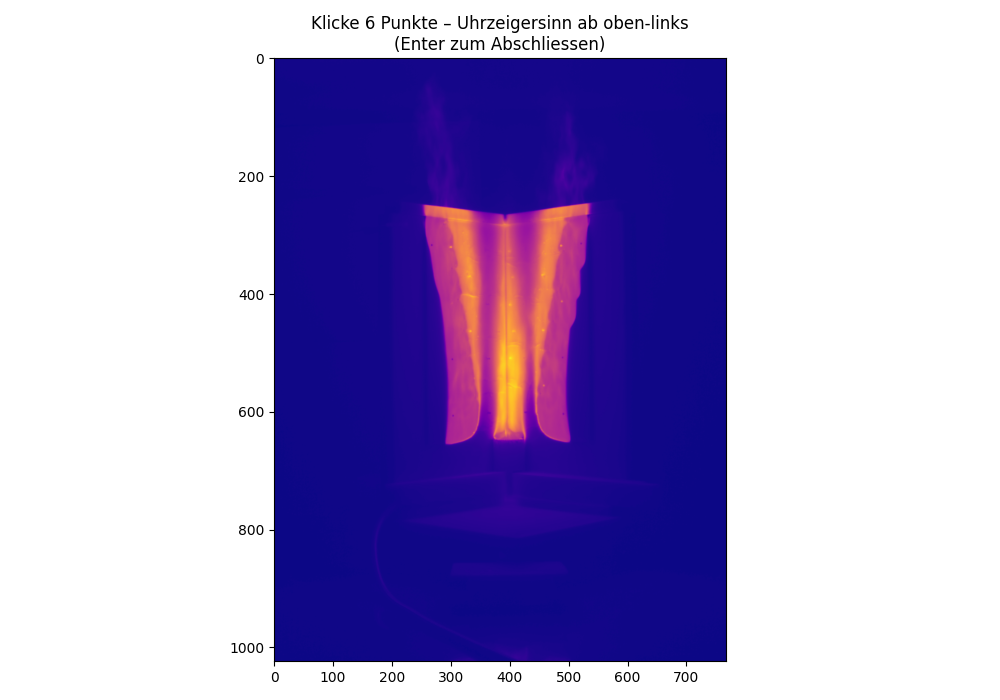

In [ ]:
# ── Anpassen ──────────────────────────────────────────────────────────────────
EXPERIMENT_TYPE = "Room Corner"   # oder "Lateral Flame Spread"
# ──────────────────────────────────────────────────────────────────────────────

N_POINTS = 6 if EXPERIMENT_TYPE == "Room Corner" else 4

fig, ax = plt.subplots(figsize=(10, 7))
ax.imshow(rotated, cmap='plasma', origin='upper')
ax.set_title(
    f"Klicke {N_POINTS} Punkte – Uhrzeigersinn ab oben-links\n"
    "(Enter zum Abschliessen)"
)
plt.tight_layout()
plt.show()

clicked_points = plt.ginput(N_POINTS, timeout=0)

print(f"Geklickte Punkte im rotierten Koordinatensystem (rotation_index={ROTATION_INDEX}):")
for i, (x, y) in enumerate(clicked_points):
    print(f"  [{i}]  x={x:.1f}  y={y:.1f}")

## Zelle 4 – `rotate_points` anwenden & Punkte im Originalbild prüfen

Die roten Punkte im **rechten Bild** müssen auf den gleichen physischen Ecken liegen
wie die Punkte im linken Bild – nur eben im unrotierten Originalframe.

In [ ]:
# Rücktransformation: rotiertes Koordinatensystem → Original
original_coords = rotate_points(clicked_points, raw.shape, ROTATION_INDEX)

print("Rücktransformierte Punkte (unrotiertes Originalbild):")
for i, (x, y) in enumerate(original_coords):
    print(f"  [{i}]  x={x:.1f}  y={y:.1f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].imshow(rotated, cmap='plasma', origin='upper')
axes[0].set_title(f'Rotiert (index={ROTATION_INDEX}) – geklickte Punkte')
for i, (x, y) in enumerate(clicked_points):
    axes[0].plot(x, y, 'ro', markersize=9)
    axes[0].annotate(str(i), (x + 4, y - 4), color='white', fontsize=10, fontweight='bold')

axes[1].imshow(raw, cmap='plasma', origin='upper')
axes[1].set_title('Original – rücktransformierte Punkte')
for i, (x, y) in enumerate(original_coords):
    axes[1].plot(x, y, 'ro', markersize=9)
    axes[1].annotate(str(i), (x + 4, y - 4), color='white', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

## Zelle 5 – Dewarping: Room Corner

Erwartet 6 Punkte aus Zelle 4 in der Reihenfolge:  
`[0]=TL, [1]=TC, [2]=TR, [3]=BR, [4]=BC, [5]=BL`

Linkes Panel = Indizes `[0,1,4,5]`, rechtes Panel = `[1,2,3,4]`.

In [ ]:
assert EXPERIMENT_TYPE == "Room Corner", "Diese Zelle ist nur für Room Corner (6 Punkte)"

# ── Ausgabegröße anpassen ─────────────────────────────────────────────────────
TARGET_W = 200
TARGET_H = 280
# ──────────────────────────────────────────────────────────────────────────────

pts = np.array(original_coords, dtype=np.float32)
pts_left  = pts[[0, 1, 4, 5]]
pts_right = pts[[1, 2, 3, 4]]


def dewarp_panel(frame, pts4, w, h):
    """Führt Remap-Dewarping auf einem einzelnen Frame durch."""
    params = get_dewarp_parameters(
        pts4, target_pixels_width=w, target_pixels_height=h, target_ratio=h / w
    )
    H_mat = np.asarray(params["transformation_matrix"], dtype=np.float32)
    H_inv = np.linalg.inv(H_mat)
    src_x, src_y = compute_remap_from_homography(H_inv, w, h)
    map_x, map_y = cv2.convertMaps(src_x, src_y, cv2.CV_16SC2)
    return cv2.remap(
        frame.astype(np.float32),
        np.clip(map_x, 0, frame.shape[1] - 1),
        np.clip(map_y, 0, frame.shape[0] - 1),
        cv2.INTER_LINEAR,
    )


left_result  = dewarp_panel(raw, pts_left,  TARGET_W, TARGET_H)
right_result = dewarp_panel(raw, pts_right, TARGET_W, TARGET_H)

fig, axes = plt.subplots(1, 3, figsize=(16, 6))
axes[0].imshow(raw,          cmap='plasma', origin='upper'); axes[0].set_title('Original')
axes[1].imshow(left_result,  cmap='plasma', origin='upper'); axes[1].set_title('Dewarped LEFT')
axes[2].imshow(right_result, cmap='plasma', origin='upper'); axes[2].set_title('Dewarped RIGHT')
plt.tight_layout()
plt.show()

## Zelle 5b – Dewarping: Lateral Flame Spread

Erwartet 4 Punkte aus Zelle 4.

In [ ]:
assert EXPERIMENT_TYPE == "Lateral Flame Spread", "Diese Zelle ist nur für LFS (4 Punkte)"

# ── Ausgabegröße anpassen ─────────────────────────────────────────────────────
TARGET_W = 300
TARGET_H = 240
# ──────────────────────────────────────────────────────────────────────────────

# LFS: rotate_points wird NICHT aufgerufen – Punkte im rotierten System,
# Dewarping arbeitet mit dem rotierten Frame
sorted_pts = sort_corner_points(clicked_points, experiment_type="Lateral Flame Spread")
params = get_dewarp_parameters(
    sorted_pts,
    target_pixels_width=TARGET_W,
    target_pixels_height=TARGET_H,
    target_ratio=TARGET_H / TARGET_W,
)
H_mat    = np.asarray(params["transformation_matrix"], dtype=np.float32)
dewarped = cv2.warpPerspective(
    rotated.astype(np.float32), H_mat, (TARGET_W, TARGET_H), flags=cv2.INTER_LINEAR
)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(rotated,  cmap='plasma', origin='upper'); axes[0].set_title('Rotiert')
axes[1].imshow(dewarped, cmap='plasma', origin='upper'); axes[1].set_title('Dewarped (LFS)')
plt.tight_layout()
plt.show()